# Student Performance Indicator

Life cycle of Machine Learning Project

- understanding the problem
- data collection
- data checks to perform
- exploratory data analysis
- model training
- choose the best model

## 1. Problem Statement
- This project understands how the student's performance (test scores) is affected by other variables such as Gender, Ethnicity, Parental level of education, Lunch and Test preparation course.

## 2. Data Collectionn
- Data Scouce: click [here](https://www.kaggle.com/datasets/spscientist/students-performance-in-exams?datasetId=74977) to navigate to data source in kaggle.
- The data has 8 columns and 1000 rows.

### 2.1 Import data and required packages
**Importing Pandas, NumPy, Matplotlib, Seaborn and Warnings Library**

In [31]:
import numpy as np
import pandas as pd
import seaborn as sns
import json
import matplotlib.pyplot as plt
from string_cleaner import clean_string
import warnings

warnings.filterwarnings("ignore")

**Import the CSV data as pandas dataframe**

In [32]:
students = pd.read_csv("./data/students.csv")

In [33]:
students

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


**Clean the column names**

In [34]:
students = students.rename(
    columns=clean_string
)

In [35]:
students

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


In [36]:
students.shape

(1000, 8)

### 2.2 Dataset Information
| Column Name                 | Description                                   | Possible Values                                                                   |
|:----------------------------|:----------------------------------------------|:----------------------------------------------------------------------------------|
| gender                      | Sex of the student                            | Male, Female                                                                      |
| race/ethnicity              | Ethnicity group of the student                | Group A, Group B, Group C, Group D, Group E                                       |
| parental level of education | Parents' highest level of education           | Bachelor's degree, Some college, Master's degree, Associate's degree, High school |
| lunch                       | Whether the student had lunch before the test | Standard, Free/Reduced                                                            |
| test preparation course     | Completion status of test preparation course  | Completed, Not completed                                                          |
| math score                  | Score obtained in math                        | Numeric (0–100)                                                                   |
| reading score               | Score obtained in reading                     | Numeric (0–100)                                                                   |
| writing score               | Score obtained in writing                     | Numeric (0–100)                                                                   |

## 3. Data check to Perform
- Check missing values
- Check for duplicates
- Check data types
- Check unique values in each column
- Check for statistics of data set
- Check different categories in various categorical columns


### 3.1 Check missing values

In [37]:
students.isnull().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

**Fortunately there are no null values in the data set**

### 3.2 Check for duplicates

In [38]:
students.duplicated().sum()

np.int64(0)

**There are no duplcates in the dataset**

### 3.3 Check data types

In [39]:
students.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race_ethnicity               1000 non-null   str  
 2   parental_level_of_education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test_preparation_course      1000 non-null   str  
 5   math_score                   1000 non-null   int64
 6   reading_score                1000 non-null   int64
 7   writing_score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


### 3.4 Checking the number of values in each columns

In [40]:
students.nunique()

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

**The above table shows how each column have how many duplicates**

### 3.5 Check statistics of data

In [41]:
students.describe(
    include = "all"
)

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
count,1000,1000,1000,1000,1000,1000.00000,1000.000000,1000.000000
unique,2,5,6,2,2,NaN,NaN,NaN
top,female,group C,some college,standard,none,NaN,NaN,NaN
freq,518,319,226,645,642,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,66.08900,69.169000,68.054000
std,NaN,NaN,NaN,NaN,NaN,15.16308,14.600192,15.195657
min,NaN,NaN,NaN,NaN,NaN,0.00000,17.000000,10.000000
25%,NaN,NaN,NaN,NaN,NaN,57.00000,59.000000,57.750000
50%,NaN,NaN,NaN,NaN,NaN,66.00000,70.000000,69.000000
75%,NaN,NaN,NaN,NaN,NaN,77.00000,79.000000,79.000000


#### Insights:
- There are three numerical columns: `math_score`, `reading_score`, `writing_score`.
- The means of all these three columns are very much close to each other: between `66.08` and `69.19`.
- The standard deviations of all these numerical columns are very much close too: between `14.60` and `15.19`.
- Math Score has a minimum of `0.00`, Reading Score has a minimum of `17.00` while Writing Score has a minimum of `10.00`.

### 3.6 Exploring Data

In [42]:
students.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [43]:
categories = {column_name: list(students[column_name].unique()) for column_name in students.select_dtypes(exclude=["number"]).columns}

In [44]:
print("Shown below are the different categories for each variable in students dataframe:")
print(json.dumps(categories, indent=4))

Shown below are the different categories for each variable in students dataframe:
{
    "gender": [
        "female",
        "male"
    ],
    "race_ethnicity": [
        "group B",
        "group C",
        "group A",
        "group D",
        "group E"
    ],
    "parental_level_of_education": [
        "bachelor's degree",
        "some college",
        "master's degree",
        "associate's degree",
        "high school",
        "some high school"
    ],
    "lunch": [
        "standard",
        "free/reduced"
    ],
    "test_preparation_course": [
        "none",
        "completed"
    ]
}


In [45]:
column_distribution = {
    "numerical_columns": [column for column in students.select_dtypes(include=["number"]).columns],
    "non_numerical_columns": [column for column in students.select_dtypes(exclude=["number"]).columns]
}

In [46]:
print("Shown below is the distirbution of column type:")
print(json.dumps(column_distribution, indent=4))
print("We have 3 numerical and 5 non_numerical columns.")

Shown below is the distirbution of column type:
{
    "numerical_columns": [
        "math_score",
        "reading_score",
        "writing_score"
    ],
    "non_numerical_columns": [
        "gender",
        "race_ethnicity",
        "parental_level_of_education",
        "lunch",
        "test_preparation_course"
    ]
}
We have 3 numerical and 5 non_numerical columns.


### 3.7 Feature Engineering: Adding total_score and avg_score columns

In [47]:
students["total_score"] = students["math_score"] + students["reading_score"] + students["writing_score"]
students["avg_score"] = students["total_score"] / 3

In [48]:
students.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,avg_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [49]:
full_score_counts = {
    f"full_{column}_count": f"{students[students[column] == 100]["avg_score"].count()} students" for column in students.select_dtypes(include=["number"]).columns
}
print("Shown below are the number of students who have scored 100 percent of total score in different subjects:")
print(json.dumps(full_score_counts, indent=4))

Shown below are the number of students who have scored 100 percent of total score in different subjects:
{
    "full_math_score_count": "7 students",
    "full_reading_score_count": "17 students",
    "full_writing_score_count": "14 students",
    "full_total_score_count": "0 students",
    "full_avg_score_count": "3 students"
}


In [50]:
less_than_20_score_counts = {
    f"less_than_20l_{column}_count": f"{students[students[column] <= 20]["avg_score"].count()} students" for column in students.select_dtypes(include=["number"]).columns
}
print("Shown below are the number of students who have scored less than 20 percent of total score in different subjects:")
print(json.dumps(less_than_20_score_counts, indent=4))

Shown below are the number of students who have scored less than 20 percent of total score in different subjects:
{
    "less_than_20l_math_score_count": "4 students",
    "less_than_20l_reading_score_count": "1 students",
    "less_than_20l_writing_score_count": "3 students",
    "less_than_20l_total_score_count": "0 students",
    "less_than_20l_avg_score_count": "2 students"
}


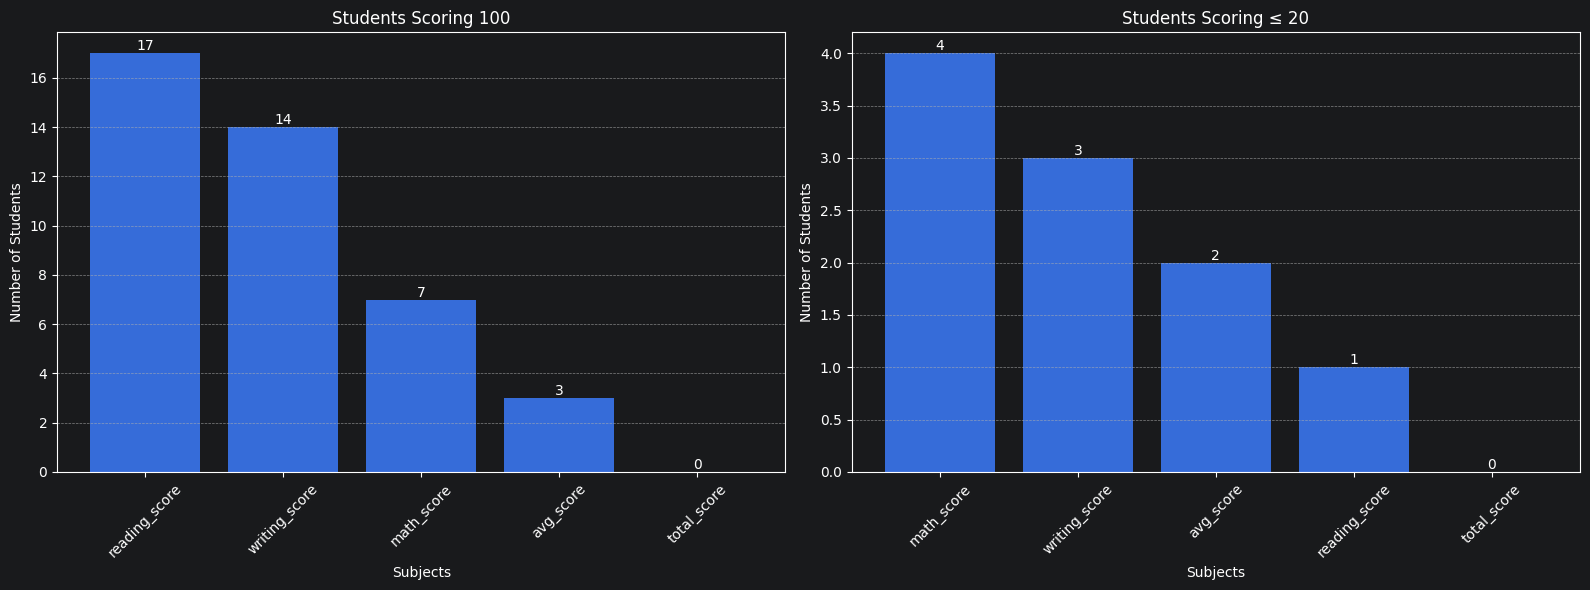

In [51]:
import matplotlib.pyplot as plt

# Extract labels and values
full_labels = [key.replace("full_", "").replace("_count", "") for key in full_score_counts.keys()]
full_values = [int(value.split(" ")[0]) for value in full_score_counts.values()]

full_data = sorted(zip(full_labels, full_values), key=lambda x: x[1], reverse=True)
full_labels, full_values = zip(*full_data)

less_labels = [key.replace("less_than_20l_", "").replace("_count", "") for key in less_than_20_score_counts.keys()]
less_values = [int(value.split(" ")[0]) for value in less_than_20_score_counts.values()]

less_data = sorted(zip(less_labels, less_values), key=lambda x: x[1], reverse=True)
less_labels, less_values = zip(*less_data)

# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6), squeeze=False)

# -------- Plot 1: Full Scores --------
bars1 = axes[0, 0].bar(full_labels, full_values)
axes[0, 0].set_title("Students Scoring 100")
axes[0, 0].set_xlabel("Subjects")
axes[0, 0].set_ylabel("Number of Students")
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(True, axis='y', linestyle='--', alpha=0.7)

# Add value labels
for bar in bars1:
    height = bar.get_height()
    axes[0, 0].text(bar.get_x() + bar.get_width()/2, height, str(height), ha='center', va='bottom')

# -------- Plot 2: Less Than 20 --------
bars2 = axes[0, 1].bar(less_labels, less_values)
axes[0, 1].set_title("Students Scoring ≤ 20")
axes[0, 1].set_xlabel("Subjects")
axes[0, 1].set_ylabel("Number of Students")
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(True, axis='y', linestyle='--', alpha=0.7)

# Add value labels
for bar in bars2:
    height = bar.get_height()
    axes[0, 1].text(bar.get_x() + bar.get_width()/2, height, str(height), ha='center', va='bottom')

# Layout adjustment
plt.tight_layout()
plt.show()

**Insights:**

From the above graphs, it can be incurred that:
- students have performed worst in math.
- students have performed best in reading.

## 4. Exploratory Data Analysis: Visualizations
### 4.1 Average Score Distributin
- Histograms.
- Kernel Distribution Function (KDE)

#### 4.1.1 Histogram and KDE

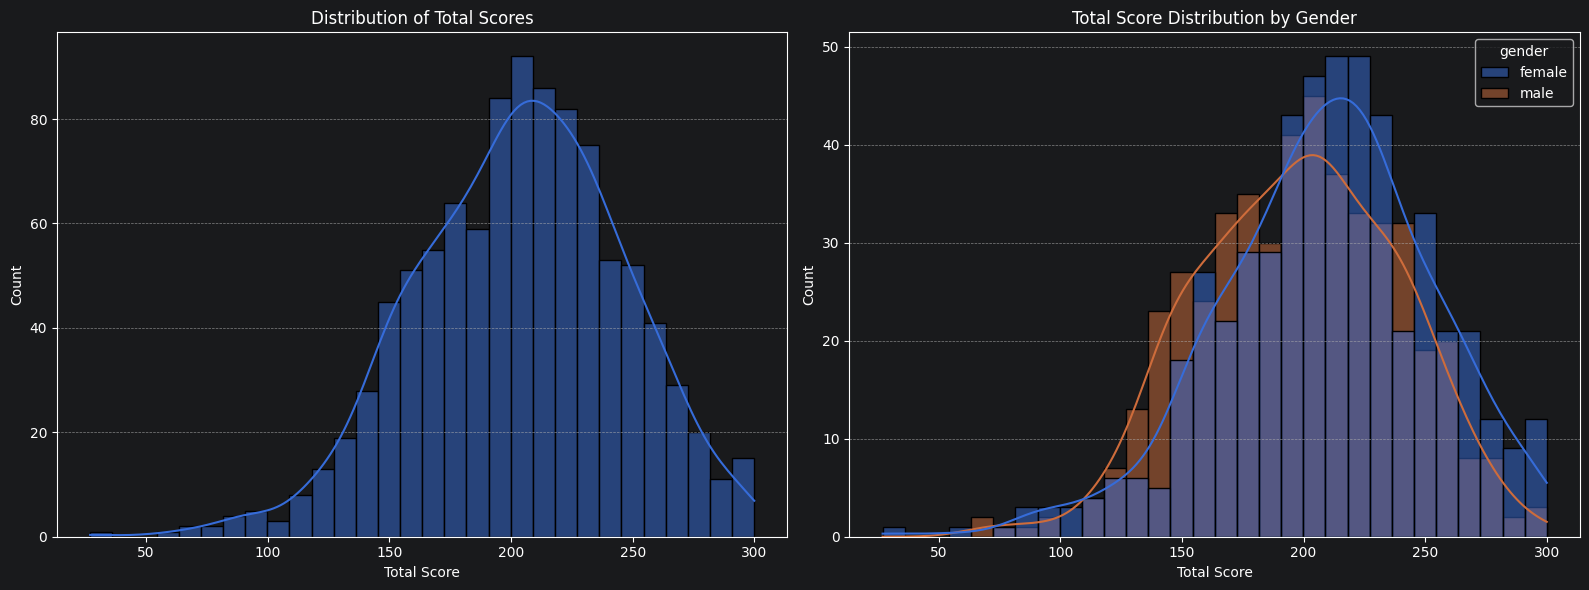

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 6), squeeze=False)

# -------- Plot 1 --------
sns.histplot(
    data=students,
    x="total_score",
    bins=30,
    kde=True,
    ax=axes[0, 0]
)
axes[0, 0].set_title("Distribution of Total Scores")
axes[0, 0].set_xlabel("Total Score")
axes[0, 0].set_ylabel("Count")
axes[0, 0].grid(True, axis='y', linestyle='--', alpha=0.7)

# -------- Plot 2 --------
sns.histplot(
    data=students,
    x="total_score",
    bins=30,
    kde=True,
    hue="gender",
    ax=axes[0, 1]
)
axes[0, 1].set_title("Total Score Distribution by Gender")
axes[0, 1].set_xlabel("Total Score")
axes[0, 1].set_ylabel("Count")
axes[0, 1].grid(True, axis='y', linestyle='--', alpha=0.7)

# Layout
plt.tight_layout()
plt.show()